In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Core libraries
import qiskit
from qiskit import QuantumCircuit

# Modules
from src.runners import run_circuit, energy_expectation
from src.transformations import (
    identity_transformation,
    barrier_only,
    commute_independent
)
from src.checker import check_violation, print_comparison

# Analysis
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("All imports successful")
print("Qiskit version:", qiskit.__version__)

All imports successful
Qiskit version: 2.3.0


In [3]:
#Config
SHOTS = 10000
SEED = 42

results = []

def record_result(name, tvd_dist, violation, p_val):
    results.append({
        "test": name,
        "tvd": tvd_dist,
        "p_value": p_val,
        "violation": violation
    })

# 1. Bell state – identity transformation

In [6]:
print("=== Identity Transformation Test ===\n")

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

qc_follow = identity_transformation(qc, seed=SEED)

counts_source = run_circuit(qc, shots=SHOTS)
counts_follow = run_circuit(qc_follow, shots=SHOTS)

tvd_viol, tvd_dist, chi_viol, p_val, _ = check_violation(
    counts_source, counts_follow, tvd_threshold=0.05
)

violation = tvd_viol or chi_viol

print(f"TVD: {tvd_dist:.4f}, p-value: {p_val:.4f}, violation: {violation}")
print("Expected: False\n")

record_result("identity", tvd_dist, violation, p_val)
print_comparison(counts_source, counts_follow)

=== Identity Transformation Test ===

TVD: 0.0039, p-value: 0.5910, violation: False
Expected: False


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
   00 |      0.4978 |         0.5017 | 0.0039
   11 |      0.5022 |         0.4983 | 0.0039


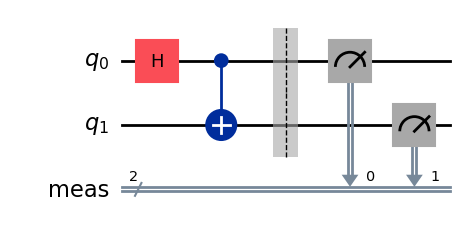

In [7]:
qc.draw("mpl")

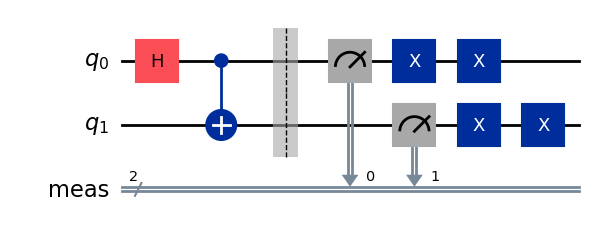

In [8]:
qc_follow.draw("mpl")

# 2. Intentional violation – flip X gate

In [9]:
print("\n=== Weak Fault (single X) ===\n")

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

qc_bad = qc.copy()
qc_bad.x(0)
qc_bad.measure_all()

counts_source = run_circuit(qc, shots=SHOTS)
counts_bad = run_circuit(qc_bad, shots=SHOTS)

tvd_viol, tvd_dist, chi_viol, p_val, _ = check_violation(
    counts_source, counts_bad, tvd_threshold=0.05
)

violation = tvd_viol or chi_viol

print(f"TVD: {tvd_dist:.4f}, p-value: {p_val:.4f}, violation: {violation}")
print("Expected: sometimes False (weak fault)\n")

record_result("weak_fault", tvd_dist, violation, p_val)
print_comparison(counts_source, counts_bad)


=== Weak Fault (single X) ===

TVD: 1.0000, p-value: 0.0000, violation: True
Expected: sometimes False (weak fault)


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
   00 |      0.4920 |         0.0000 | 0.4920
01 00 |      0.0000 |         0.4978 | 0.4978
10 11 |      0.0000 |         0.5022 | 0.5022
   11 |      0.5080 |         0.0000 | 0.5080


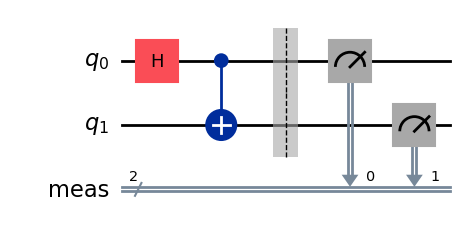

In [10]:
qc.draw("mpl")


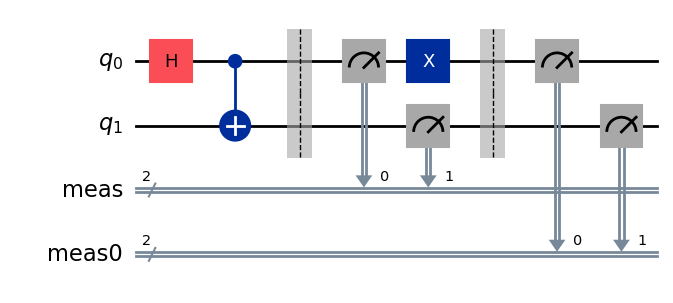

In [11]:
qc_bad.draw("mpl")

In [12]:
print("\n=== Strong Fault (X on both qubits) ===\n")

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

qc_bad = qc.copy()
qc_bad.x(0)
qc_bad.x(1)
qc_bad.measure_all()

counts_source = run_circuit(qc, shots=SHOTS)
counts_bad = run_circuit(qc_bad, shots=SHOTS)

tvd_viol, tvd_dist, chi_viol, p_val, _ = check_violation(
    counts_source, counts_bad, tvd_threshold=0.05
)

violation = tvd_viol or chi_viol

print(f"TVD: {tvd_dist:.4f}, p-value: {p_val:.6f}, violation: {violation}")
print("Expected: True\n")

record_result("strong_fault", tvd_dist, violation, p_val)
print_comparison(counts_source, counts_bad)


=== Strong Fault (X on both qubits) ===

TVD: 1.0000, p-value: 0.000000, violation: True
Expected: True


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
   00 |      0.5066 |         0.0000 | 0.5066
00 11 |      0.0000 |         0.4998 | 0.4998
   11 |      0.4934 |         0.0000 | 0.4934
11 00 |      0.0000 |         0.5002 | 0.5002


# 3. Barrier insertion

In [13]:
print("\n=== Barrier Test ===\n")

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

qc_barrier = barrier_only(qc, seed=SEED)

counts_source = run_circuit(qc, shots=SHOTS)
counts_barrier = run_circuit(qc_barrier, shots=SHOTS)

tvd_viol, tvd_dist, chi_viol, p_val, _ = check_violation(
    counts_source, counts_barrier, tvd_threshold=0.05
)

violation = tvd_viol or chi_viol

print(f"TVD: {tvd_dist:.4f}, p-value: {p_val:.4f}, violation: {violation}")
print("Expected: False\n")

record_result("barrier", tvd_dist, violation, p_val)
print_comparison(counts_source, counts_barrier)


=== Barrier Test ===

TVD: 0.0056, p-value: 0.4367, violation: False
Expected: False


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
   00 |      0.4979 |         0.5035 | 0.0056
   11 |      0.5021 |         0.4965 | 0.0056


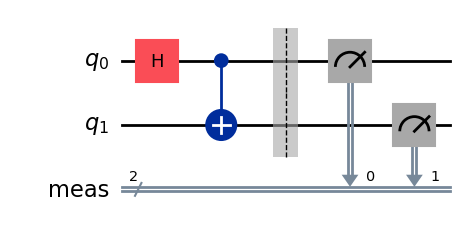

In [14]:
qc.draw('mpl')


Barrier-inserted circuit:


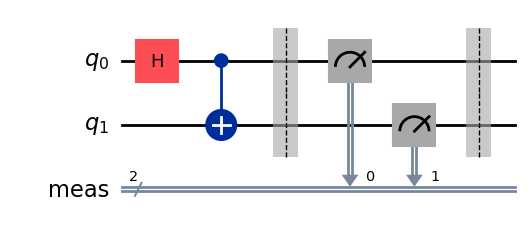

In [15]:
print("\nBarrier-inserted circuit:")
qc_barrier.draw('mpl')


# 4. Commutation of independent gates test

In [16]:
print("\n=== Commutation Test ===\n")

qc = QuantumCircuit(3)
qc.h(0)
qc.x(1)
qc.z(2)
qc.cx(0, 2)
qc.measure_all()

qc_follow = commute_independent(qc, seed=SEED)

counts_source = run_circuit(qc, shots=SHOTS)
counts_follow = run_circuit(qc_follow, shots=SHOTS)

tvd_viol, tvd_dist, chi_viol, p_val, _ = check_violation(
    counts_source, counts_follow, tvd_threshold=0.05
)

violation = tvd_viol or chi_viol

print(f"TVD: {tvd_dist:.4f}, p-value: {p_val:.4f}, violation: {violation}")
print("Expected: False\n")

record_result("commute", tvd_dist, violation, p_val)
print_comparison(counts_source, counts_follow)


=== Commutation Test ===

TVD: 0.0006, p-value: 0.9436, violation: False
Expected: False


State | Source Prob | Follow-up Prob | Diff
--------------------------------------------
  010 |      0.4997 |         0.5003 | 0.0006
  111 |      0.5003 |         0.4997 | 0.0006


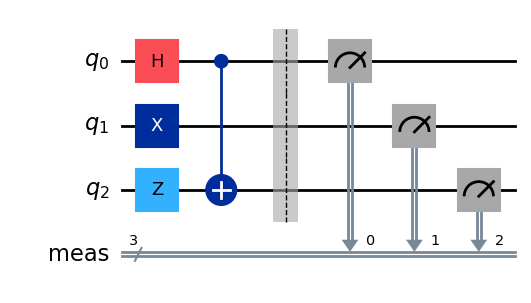

In [17]:
qc.draw('mpl')   

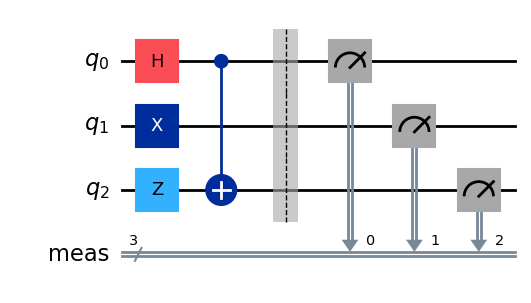

In [18]:
qc_follow.draw('mpl')


In [19]:
df = pd.DataFrame(results)
display(df)

,test,tvd,p_value,violation
0,identity,0.0117,0.100901,False
1,identity,0.0039,0.590991,False
2,weak_fault,1.0000,0.000000,True
3,strong_fault,1.0000,0.000000,True
4,barrier,0.0056,0.436676,False
5,commute,0.0006,0.943628,False


In [20]:
# ────────────────────────────────────────────────
# Minimal VQE check (identity relation)
# ────────────────────────────────────────────────

from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import efficient_su2
from scipy.optimize import minimize

print("\n=== VQE Check (Identity Relation) ===\n")

# Hamiltonian
H = SparsePauliOp(["ZZ", "IX", "XI"], coeffs=[-1.0, 0.5, 0.5])

# Ansatz
ansatz = efficient_su2(2, reps=2, entanglement="full")

# Identity transformation
ansatz_id = ansatz.copy()
ansatz_id.x(0)
ansatz_id.x(0)

# Initial point
np.random.seed(42)
init = np.random.uniform(-0.1, 0.1, ansatz.num_parameters)


=== VQE Check (Identity Relation) ===



In [21]:
def energy(ansatz, params):
    bound = ansatz.assign_parameters(params)
    sv = Statevector.from_instruction(bound)
    return float(np.real(sv.expectation_value(H)))

In [22]:
def run_vqe(ansatz):
    energies = []

    def objective(params):
        e = energy(ansatz, params)
        energies.append(e)
        return e

    result = minimize(objective, init, method="COBYLA", options={"maxiter": 30})
    return result, energies

In [23]:
res_src, trace_src = run_vqe(ansatz)
res_id, trace_id = run_vqe(ansatz_id)

delta_E = abs(res_src.fun - res_id.fun)

print("Source final energy:", res_src.fun)
print("Follow-up final energy:", res_id.fun)
print("ΔE:", delta_E)

print("\nExpected: ΔE ≈ 0")

Source final energy: -1.3852023572405805
Follow-up final energy: -1.3852023572405805
ΔE: 0.0

Expected: ΔE ≈ 0


In [24]:
ansatz_fault = ansatz.copy()
ansatz_fault.x(0)

res_fault, _ = run_vqe(ansatz_fault)

print("Fault ΔE:", abs(res_src.fun - res_fault.fun))

Fault ΔE: 0.08146014294899317
